<a href="https://colab.research.google.com/github/anyuanay/INFO212/blob/main/FARR_STEM_Module3_2_data_visualization_5_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FARR-STEM Program
## Module 3.2: Data Visualization Patterns
### Yuan An, PhD
### College of Computing and Informatics
### Drexel University

## Hands-on Workshop


## Setup: Run This First

Install and import all dependencies used throughout the module.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy as sp

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Notebook-wide style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Shared color palette
PALETTE = {
    'blue':    '#2563EB',
    'green':   '#059669',
    'amber':   '#D97706',
    'red':     '#DC2626',
    'violet':  '#7C3AED',
    'cyan':    '#0891B2',
    'orange':  '#F97316',
    'gray':    '#6B7280',
}
CAT_COLORS = [PALETTE['blue'], PALETTE['green'], PALETTE['amber'],
              PALETTE['red'], PALETTE['violet'], PALETTE['cyan']]

REGION_COLORS = {
    'Europe': '#2563EB', 'Americas': '#059669',
    'Asia': '#D97706', 'Africa': '#DC2626', 'Oceania': '#7C3AED'
}

## Datasets

All datasets used throughout the module are defined here. Run this cell before any unit.

In [2]:
# Dataset 1: Exam Scores (n=30)
exam_scores = np.array([
    72, 85, 91, 68, 77, 83, 79, 92, 65, 88,
    76, 84, 71, 89, 80, 74, 87, 95, 66, 82,
    78, 90, 73, 86, 81, 69, 93, 75, 88, 70
])

# Dataset 2: Apartment Rental Prices ($)
rental_prices = np.array([
     850,  920, 1100, 1850, 1200,  975, 1050, 1400, 1650,  890,
    1300, 1750, 2100,  980, 1125, 1450, 1600,  925, 1075, 3200,
    1350, 1250, 1550, 2400,  895, 1175, 1425, 1700,  950, 1000
])

# Dataset 3: Adult Heights (cm)
heights = np.array([
    162, 158, 170, 175, 164, 168, 172, 160, 176, 163,
    169, 171, 165, 174, 167, 173, 161, 178, 166, 179,
    159, 177, 164, 170, 168, 172, 161, 175, 166, 180,
    163, 169, 157, 174, 171, 165, 176, 168, 162, 172
])

# Dataset 4: World Health (Gapminder-style)
world_health = pd.DataFrame([
    ('Norway',      'Europe',   67200, 83.2,  5.4),
    ('USA',         'Americas', 65000, 78.5,  331),
    ('Australia',   'Oceania',  52800, 83.4,   25),
    ('Sweden',      'Europe',   51600, 82.7,   10),
    ('Germany',     'Europe',   45700, 81.0,   83),
    ('Canada',      'Americas', 43300, 82.3,   38),
    ('France',      'Europe',   40500, 82.5,   68),
    ('UK',          'Europe',   40300, 81.3,   67),
    ('Japan',       'Asia',     40000, 84.3,  126),
    ('S. Korea',    'Asia',     31500, 83.5,   52),
    ('Mexico',      'Americas',  9900, 75.1,  129),
    ('Argentina',   'Americas',  9900, 76.7,   45),
    ('China',       'Asia',     10500, 77.3, 1440),
    ('Brazil',      'Americas',  8900, 75.7,  215),
    ('Egypt',       'Africa',    3600, 72.0,  102),
    ('S. Africa',   'Africa',    6000, 64.1,   60),
    ('Indonesia',   'Asia',      4200, 71.7,  274),
    ('India',       'Asia',      2100, 69.7, 1380),
    ('Nigeria',     'Africa',    2100, 62.3,  206),
    ('Ethiopia',    'Africa',     840, 66.5,  115),
], columns=['country', 'region', 'gdp_per_capita', 'life_expectancy', 'population_M'])

# Dataset 5: Monthly Retail Sales ($K)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_sales = pd.DataFrame({
    'month':       months,
    'electronics': [42, 38, 45, 51, 48, 55, 60, 58, 52, 64,  89,  95],
    'clothing':    [35, 32, 48, 52, 58, 45, 43, 49, 55, 62,  78,  85],
    'furniture':   [28, 31, 44, 53, 60, 55, 52, 54, 49, 47,  58,  62],
    'food':        [88, 82, 91, 87, 93, 95, 98, 96, 92, 94, 108, 125],
})

# Dataset 6: Temperature Anomalies
temp_data = pd.DataFrame({
    'year':  [1960,1965,1970,1975,1980,1985,1990,1995,2000,2005,2010,2015,2020,2023],
    'anomaly':[-0.02,0.04,0.03,0.01,0.27,0.13,0.44,0.38,0.42,0.68,0.72,0.90,1.02,1.46]
})

print("All datasets loaded.")
print(f"   exam_scores      : n={len(exam_scores)}")
print(f"   rental_prices    : n={len(rental_prices)}")
print(f"   heights          : n={len(heights)}")
print(f"   world_health     : {world_health.shape}")
print(f"   monthly_sales    : {monthly_sales.shape}")
print(f"   temp_data        : {temp_data.shape}")


All datasets loaded.
   exam_scores      : n=30
   rental_prices    : n=30
   heights          : n=40
   world_health     : (20, 5)
   monthly_sales    : (12, 5)
   temp_data        : (14, 2)


---
# Unit 5 Hands-On Workshop

Apply everything from Units 1-4 to two real-world datasets. Your goal is not just to
make charts. It is to **find and communicate a meaningful insight**.


## Exercise 1 · Global Health & Development

**Dataset:** `world_health`: 20 countries, variables: GDP per capita, life expectancy, population, region

Complete the following analysis workflow. Starter code is provided for each step.


In [3]:
# Step 1: Descriptive statistics
print("=" * 55)
print("  STEP 1: Descriptive Statistics — World Health Data")
print("=" * 55)

gdp  = world_health['gdp_per_capita']
le   = world_health['life_expectancy']

print(f"\n  GDP per Capita")
print(f"    Mean   : ${gdp.mean():>10,.0f}")
print(f"    Median : ${gdp.median():>10,.0f}")
print(f"    Ratio  : {gdp.mean()/gdp.median():.2f}x  ← gap reveals right skew")

print(f"\n  Life Expectancy")
print(f"    Mean   : {le.mean():.1f} years")
print(f"    Median : {le.median():.1f} years")
print(f"    Std Dev: {le.std():.1f} years")
print(f"    Range  : {le.min():.1f} – {le.max():.1f} years")

print("\n  By Region:")
region_stats = world_health.groupby('region')['life_expectancy'].agg(
    Mean='mean', Std='std', Min='min', Max='max', n='count'
).round(1)
print(region_stats.to_string())


  STEP 1: Descriptive Statistics — World Health Data

  GDP per Capita
    Mean   : $    26,797
    Median : $    21,000
    Ratio  : 1.28x  ← gap reveals right skew

  Life Expectancy
    Mean   : 76.7 years
    Median : 77.9 years
    Std Dev: 6.9 years
    Range  : 62.3 – 84.3 years

  By Region:
          Mean  Std   Min   Max  n
region                            
Africa    66.2  4.2  62.3  72.0  4
Americas  77.7  2.9  75.1  82.3  5
Asia      77.3  6.6  69.7  84.3  5
Europe    82.1  0.9  81.0  83.2  5
Oceania   83.4  NaN  83.4  83.4  1


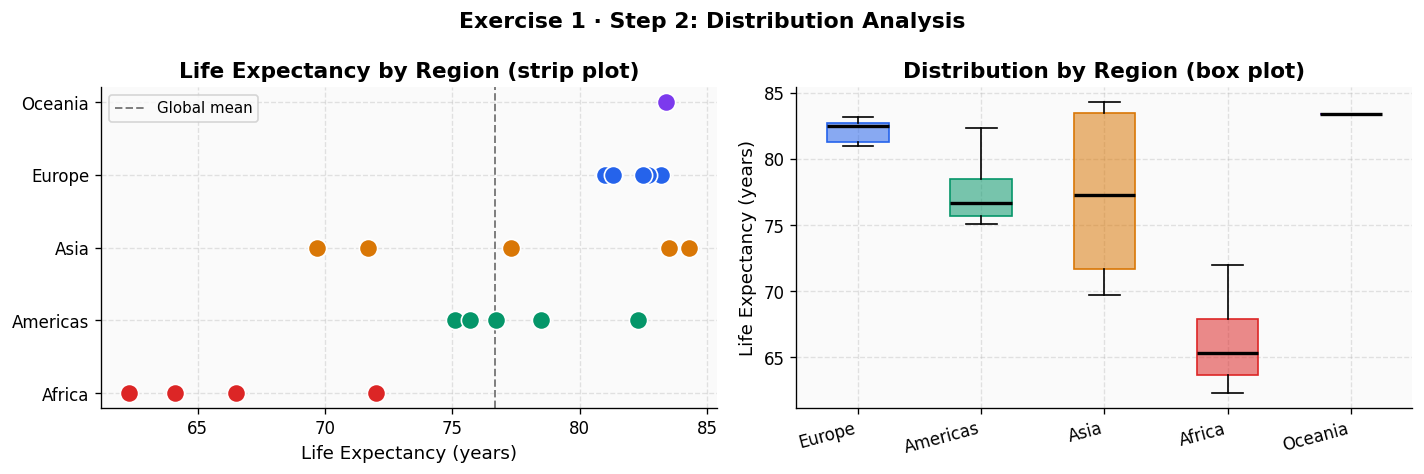


Observation: Europe/Oceania/Americas cluster high; Africa shows greatest spread.


In [4]:
# Step 2: Distribution of life expectancy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram by region
for region, group in world_health.groupby('region'):
    axes[0].scatter(group['life_expectancy'],
                    [region] * len(group),
                    color=REGION_COLORS[region], s=120,
                    edgecolors='white', linewidths=1, zorder=3)
axes[0].set_xlabel('Life Expectancy (years)')
axes[0].set_title('Life Expectancy by Region (strip plot)')
axes[0].axvline(world_health['life_expectancy'].mean(), color='gray',
                linestyle='--', linewidth=1.2, label='Global mean')
axes[0].legend(fontsize=9)

# Box plot by region
data_by_region = [world_health[world_health['region']==r]['life_expectancy'].values
                  for r in REGION_COLORS]
bp = axes[1].boxplot(data_by_region, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], REGION_COLORS.values()):
    patch.set_facecolor(color + '88')
    patch.set_edgecolor(color)
axes[1].set_xticklabels(list(REGION_COLORS.keys()), rotation=15, ha='right')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].set_title('Distribution by Region (box plot)')

fig.suptitle('Exercise 1 · Step 2: Distribution Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservation: Europe/Oceania/Americas cluster high; Africa shows greatest spread.")


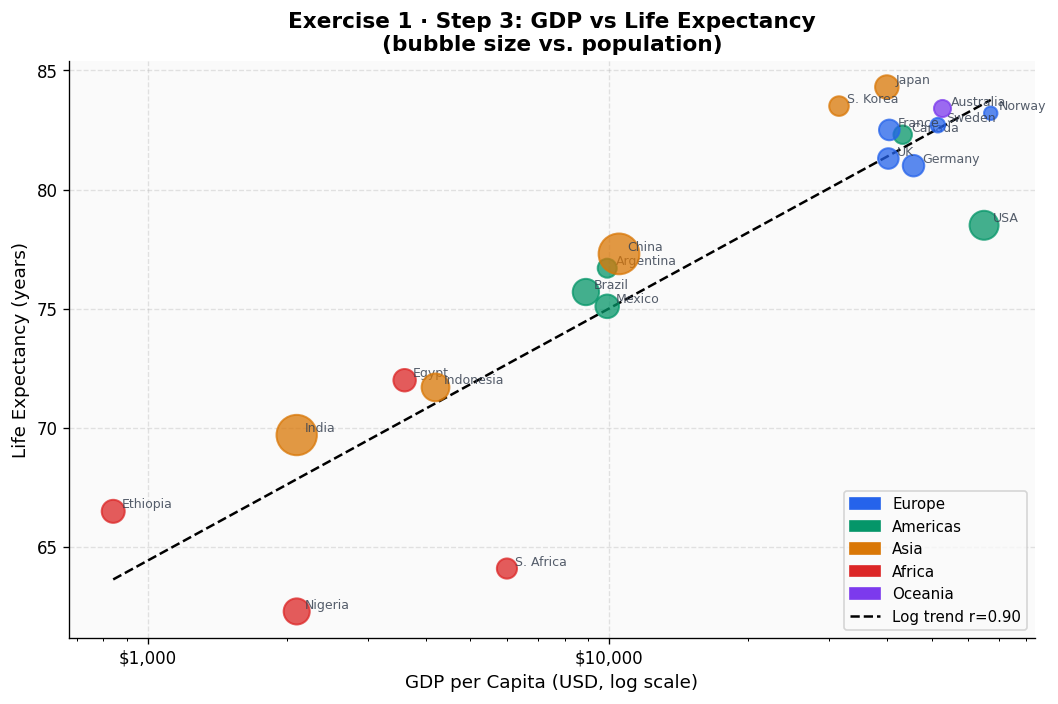


Pearson r (log GDP vs LE) = 0.897, p = 0.00000
Interpretation: Strong positive relationship on log scale. Returns to LE diminish at high GDP.


In [5]:
# Step 3: Relationship between GDP and Life Expectancy
fig, ax = plt.subplots(figsize=(9, 6))

for region, group in world_health.groupby('region'):
    sizes = np.sqrt(group['population_M']) * 15 + 30
    ax.scatter(group['gdp_per_capita'], group['life_expectancy'],
               s=sizes, color=REGION_COLORS[region], alpha=0.75,
               edgecolors=REGION_COLORS[region], linewidths=1.2, label=region, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(row['country'],
                    (row['gdp_per_capita'], row['life_expectancy']),
                    xytext=(5, 2), textcoords='offset points',
                    fontsize=7.5, color='#374151', alpha=0.85)

# Log-scale x and trend line
ax.set_xscale('log')
log_gdp = np.log(world_health['gdp_per_capita'])
life    = world_health['life_expectancy']
slope, intercept, r, p, se = stats.linregress(log_gdp, life)
x_fit = np.logspace(np.log10(world_health['gdp_per_capita'].min()),
                    np.log10(world_health['gdp_per_capita'].max()), 100)
ax.plot(x_fit, slope * np.log(x_fit) + intercept, 'k--',
        linewidth=1.5, label=f'Log trend  r={r:.2f}')

ax.set_xlabel('GDP per Capita (USD, log scale)')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Exercise 1 · Step 3: GDP vs Life Expectancy\n(bubble size vs. population)',
             fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
legend_patches.append(plt.Line2D([0],[0], linestyle='--', color='black', label=f'Log trend r={r:.2f}'))
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print(f"\nPearson r (log GDP vs LE) = {r:.3f}, p = {p:.5f}")
print("Interpretation: Strong positive relationship on log scale. Returns to LE diminish at high GDP.")


# Exercise 1: Guided Questions

1. Why is the mean GDP **much higher** than the median? Which would you headline?
2. Which country has a **higher life expectancy than its GDP predicts**? What might explain this?
3. Which region has the **greatest within-region variation** in life expectancy?
4. Write a **one-sentence insight** from this dataset that could accompany a chart in a report.
5. Which **single chart type** would you show to a World Bank executive? Why?


## Exercise 2: Retail Sales Performance

**Dataset:** `monthly_sales`: 12 months × 4 categories (electronics, clothing, furniture, food)

Conduct a full performance analysis and build a stakeholder-ready narrative.


In [6]:
# Full analysis: descriptive stats per category
cats = ['electronics', 'clothing', 'furniture', 'food']

print("=" * 65)
print("  RETAIL SALES — Descriptive Statistics by Category")
print("=" * 65)
print(f"  {'Category':<14} {'Mean':>7} {'Std':>7} {'CV%':>6} {'Min':>6} {'Max':>6} {'Q4 Avg':>8}")
print("  " + "-"*62)
for cat in cats:
    s = monthly_sales[cat]
    q4 = monthly_sales[cat].iloc[9:].mean()
    cv = s.std()/s.mean()*100
    print(f"  {cat.title():<14} {s.mean():>7.1f} {s.std():>7.1f} {cv:>5.1f}% {s.min():>6} {s.max():>6} {q4:>8.1f}")
print("=" * 65)
print("\nCV = Coefficient of Variation (lower = more stable throughout year)")


  RETAIL SALES — Descriptive Statistics by Category
  Category          Mean     Std    CV%    Min    Max   Q4 Avg
  --------------------------------------------------------------
  Electronics       58.1    17.6  30.2%     38     95     82.7
  Clothing          53.5    15.7  29.4%     32     85     75.0
  Furniture         49.4    10.7  21.6%     28     62     55.7
  Food              95.8    11.2  11.7%     82    125    109.0

CV = Coefficient of Variation (lower = more stable throughout year)


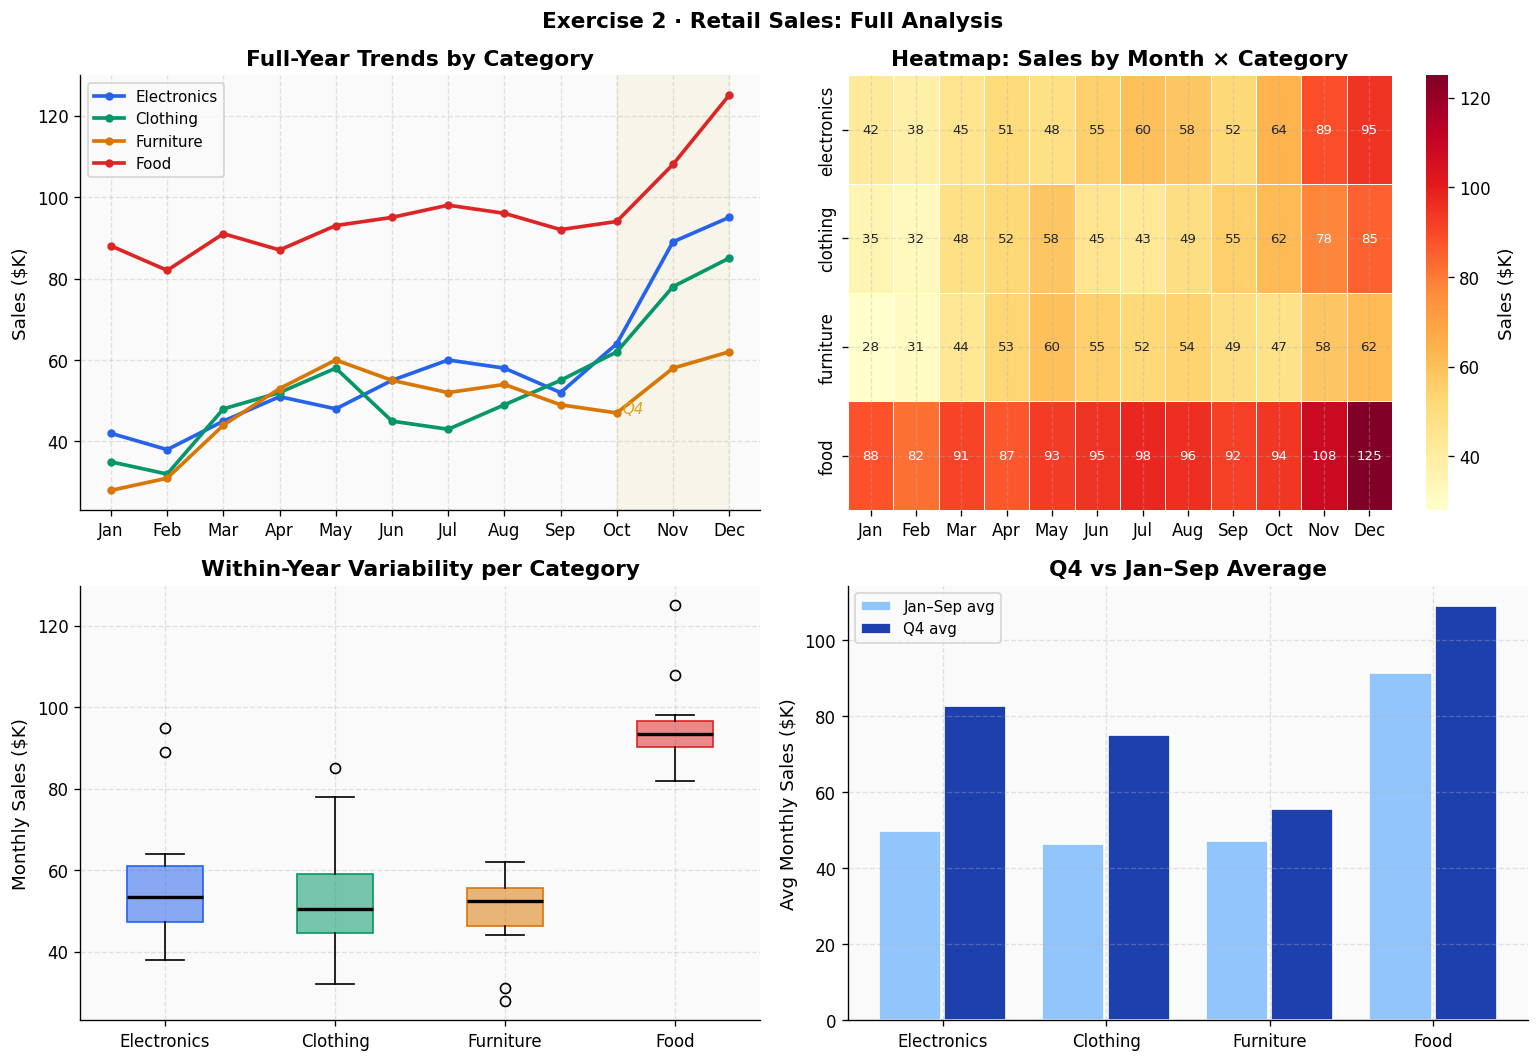

In [7]:
# Full visualization suite
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

colors_dict = {'electronics': PALETTE['blue'], 'clothing': PALETTE['green'],
               'furniture': PALETTE['amber'], 'food': PALETTE['red']}

# 1) Multi-line trend
for cat, color in colors_dict.items():
    axes[0,0].plot(months, monthly_sales[cat], marker='o', markersize=4,
                   linewidth=2.2, color=color, label=cat.title())
axes[0,0].set_title('Full-Year Trends by Category')
axes[0,0].set_ylabel('Sales ($K)')
axes[0,0].legend(fontsize=9)
axes[0,0].axvspan(9, 11, alpha=0.07, color='goldenrod')
axes[0,0].text(9.1, 47, 'Q4', fontsize=9, color='goldenrod', fontstyle='italic')

# 2) Heatmap: month × category
heat_df = monthly_sales.set_index('month')[cats]
sns.heatmap(heat_df.T, ax=axes[0,1], cmap='YlOrRd', annot=True, fmt='.0f',
            annot_kws={'size':8}, linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Sales ($K)'})
axes[0,1].set_title('Heatmap: Sales by Month × Category')
axes[0,1].set_xlabel('')

# 3) Box plot: within-year variability
bp = axes[1,0].boxplot([monthly_sales[c] for c in cats], patch_artist=True,
                        labels=[c.title() for c in cats],
                        medianprops=dict(color='black', linewidth=2))
for patch, cat in zip(bp['boxes'], cats):
    patch.set_facecolor(colors_dict[cat] + '88')
    patch.set_edgecolor(colors_dict[cat])
axes[1,0].set_ylabel('Monthly Sales ($K)')
axes[1,0].set_title('Within-Year Variability per Category')

# 4) Q4 vs rest of year bar chart
q4_avg   = {cat: monthly_sales[cat].iloc[9:].mean()   for cat in cats}
rest_avg = {cat: monthly_sales[cat].iloc[:9].mean()   for cat in cats}
x_pos = np.arange(len(cats))
axes[1,1].bar(x_pos - 0.2, [rest_avg[c] for c in cats], 0.38,
              label='Jan–Sep avg', color='#93C5FD', edgecolor='white')
axes[1,1].bar(x_pos + 0.2, [q4_avg[c]   for c in cats], 0.38,
              label='Q4 avg',       color='#1E40AF', edgecolor='white')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels([c.title() for c in cats])
axes[1,1].set_ylabel('Avg Monthly Sales ($K)')
axes[1,1].set_title('Q4 vs Jan–Sep Average')
axes[1,1].legend(fontsize=9)

fig.suptitle('Exercise 2 · Retail Sales: Full Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## Capstone Challenge 3-Chart Stakeholder Presentation

Build a three-chart narrative following the data story arc.
The template below provides the structure. Your job is to write the annotations and titles.

**Scoring rubric (1–5 each):**
| Criterion | 1 (poor) | 5 (excellent) |
|-----------|----------|---------------|
| **Accuracy** | Mislabeled axes | Fully labeled, sourced |
| **Chart type** | Wrong type for question | Ideal match |
| **Clarity** | Confusing in 30s | Insight clear in 10s |
| **Insight** | No takeaway | Clear, actionable finding |
| **Design** | Cluttered/decorative | Purposeful color, clean |


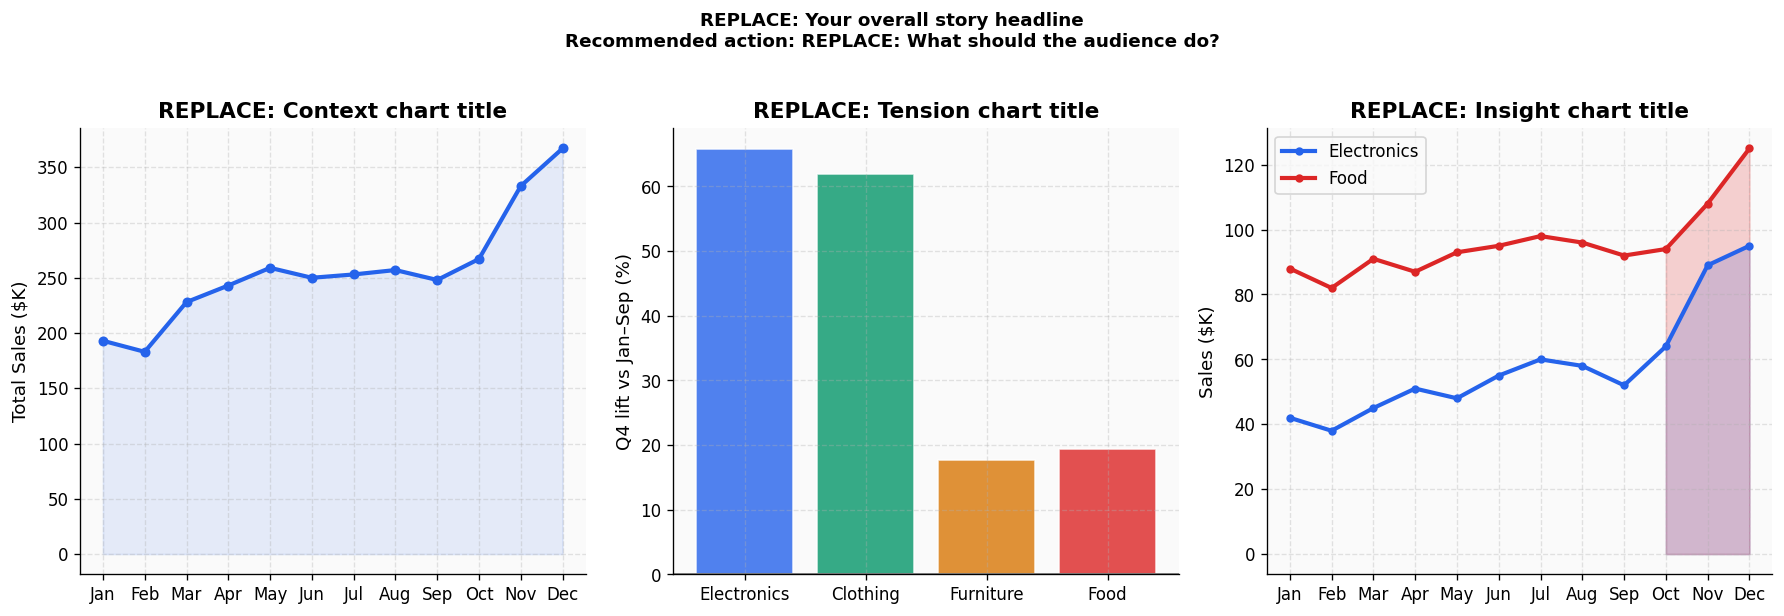


 Peer review: Share this chart with a classmate and score it using the rubric above.


In [8]:
# CAPSTONE TEMPLATE: Complete the titles, annotations, and insights
# TODO: Fill in your narrative titles and annotations

STORY_TITLE     = "REPLACE: Your overall story headline"
CHART1_TITLE    = "REPLACE: Context chart title"
CHART1_SUBTITLE = "REPLACE: What does the baseline show?"
CHART2_TITLE    = "REPLACE: Tension chart title"
CHART2_ANNOTATION = "REPLACE: What's the problem or opportunity?"
CHART3_TITLE    = "REPLACE: Insight chart title"
RECOMMENDED_ACTION = "REPLACE: What should the audience do?"

#
# USE EITHER DATASET: world_health  OR  monthly_sales
# Below is a starter using monthly_sales. Modify freely
#

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Context
total_monthly = monthly_sales[['electronics','clothing','furniture','food']].sum(axis=1)
axes[0].plot(months, total_monthly, color=PALETTE['blue'], linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(range(len(months)), total_monthly, alpha=0.1, color=PALETTE['blue'])
axes[0].set_title(CHART1_TITLE, fontweight='bold')
axes[0].set_ylabel('Total Sales ($K)')
# TODO: Add a mean reference line and label it

# Chart 2: Tension
q4_lift = {cat: (monthly_sales[cat].iloc[9:].mean() /
                  monthly_sales[cat].iloc[:9].mean() - 1) * 100
           for cat in ['electronics','clothing','furniture','food']}
bars = axes[1].bar(list(q4_lift.keys()), list(q4_lift.values()),
                   color=[PALETTE['blue'], PALETTE['green'], PALETTE['amber'], PALETTE['red']],
                   alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].set_title(CHART2_TITLE, fontweight='bold')
axes[1].set_ylabel('Q4 lift vs Jan–Sep (%)')
axes[1].set_xticklabels([c.title() for c in list(q4_lift.keys())])
# TODO: Annotate the bar showing the most surprising finding

# Chart 3: Insight
for cat, color in [('electronics', PALETTE['blue']), ('food', PALETTE['red'])]:
    axes[2].plot(months, monthly_sales[cat], color=color, linewidth=2.5,
                 marker='o', markersize=4, label=cat.title())
    # Highlight Q4
    axes[2].fill_between(range(9, 12),
                         monthly_sales[cat].values[9:],
                         alpha=0.2, color=color)
axes[2].set_title(CHART3_TITLE, fontweight='bold')
axes[2].set_ylabel('Sales ($K)')
axes[2].legend(fontsize=10)
# TODO: Add a text annotation with your key insight

fig.suptitle(STORY_TITLE + f'\nRecommended action: {RECOMMENDED_ACTION}',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Peer review: Share this chart with a classmate and score it using the rubric above.")


---
## Module Summary: The 5 Rules

| # | Rule |
|---|------|
| 1 | Always explore data with **descriptive statistics** before choosing a chart type |
| 2 | Match your chart type to your **data question** — not to what looks impressive |
| 3 | Use color to encode **meaning**, not to decorate. Gray + one accent often beats a rainbow |
| 4 | **Annotate** your key insight explicitly — never make the reader find it |
| 5 | Know your **audience**: their context, their decision, the one action you want them to take |
